In [41]:
import zipfile
import os

zip_path = "/content/aoroa_aiml_assignment_2026.zip"
extract_path = "/content/aoroa_assignment"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("ZIP extracted successfully!")


ZIP extracted successfully!


In [42]:
import os

for root, dirs, files in os.walk("/content/aoroa_assignment"):
    print("\n📁", root)
    for file in files:
        print("   📄", file)


📁 /content/aoroa_assignment

📁 /content/aoroa_assignment/aoroa_aiml_assignment_2026
   📄 requirements.txt
   📄 README.md

📁 /content/aoroa_assignment/aoroa_aiml_assignment_2026/part2_model

📁 /content/aoroa_assignment/aoroa_aiml_assignment_2026/part2_model/data
   📄 ecommerce_events.csv
   📄 forecast_target_dates.csv
   📄 DATA_CARD.md


In [28]:
df = pd.read_csv("/content/aoroa_assignment/aoroa_aiml_assignment_2026/part2_model/data/ecommerce_events.csv")

In [33]:
df.shape
df.head()
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72573 entries, 0 to 72572
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            72573 non-null  object 
 1   user_id         72573 non-null  object 
 2   payment_method  70259 non-null  object 
 3   discount_rate   72573 non-null  float64
 4   app_time_min    72573 non-null  int64  
 5   paid_amount     72573 non-null  int64  
dtypes: float64(1), int64(2), object(3)
memory usage: 3.3+ MB


,discount_rate,app_time_min,paid_amount
count,72573.000000,72573.000000,7.257300e+04
mean,0.056467,16.745815,5.470984e+04
std,0.091152,9.689030,3.113802e+04
min,0.000000,1.000000,2.000000e+03
25%,0.000000,10.000000,3.300700e+04
50%,0.000000,16.000000,5.013000e+04
75%,0.100000,23.000000,7.145700e+04
max,0.300000,65.000000,1.619435e+06


IKKINCHI QADAM AUDIT

In [39]:
import pandas as pd
import numpy as np
import os



In [44]:
# Datasetni yuklash
data_path = "/content/aoroa_assignment/aoroa_aiml_assignment_2026/part2_model/data/ecommerce_events.csv"

df = pd.read_csv(data_path)

print("Dataset loaded successfully!")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully!
Rows: 72,573
Columns: 6


In [45]:
print("=== SCHEMA ===")

print(df.columns.tolist())

print("\n=== FIRST 5 ROWS ===")
display(df.head())

=== SCHEMA ===
['date', 'user_id', 'payment_method', 'discount_rate', 'app_time_min', 'paid_amount']

=== FIRST 5 ROWS ===


,date,user_id,payment_method,discount_rate,app_time_min,paid_amount
0,2022-07-01,U0003,Voucher,0.1,13,29893
1,2022-07-01,U0589,Card,0.0,11,37530
2,2022-07-01,U0587,Card,0.0,25,53943
3,2022-07-01,U0581,Card,0.0,25,84161
4,2022-07-01,U0549,Transfer,0.0,19,49437


In [46]:
print("=== DATA TYPES ===")

df.info()

=== DATA TYPES ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72573 entries, 0 to 72572
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            72573 non-null  object 
 1   user_id         72573 non-null  object 
 2   payment_method  70259 non-null  object 
 3   discount_rate   72573 non-null  float64
 4   app_time_min    72573 non-null  int64  
 5   paid_amount     72573 non-null  int64  
dtypes: float64(1), int64(2), object(3)
memory usage: 3.3+ MB


In [49]:
print("\n=== DATA TYPE TABLE ===")

display(
    pd.DataFrame({
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "missing": df.isna().sum().values,
        "unique": df.nunique().values
    })
)


=== DATA TYPE TABLE ===


,column,dtype,missing,unique
0,date,datetime64[ns],0,703
1,user_id,object,0,800
2,payment_method,object,2314,4
3,discount_rate,float64,0,7
4,app_time_min,int64,0,63
5,paid_amount,int64,0,51253


In [50]:
df["date"] = pd.to_datetime(df["date"])

In [51]:
print("=== DUPLICATES ===")

duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count:,}")
print(f"Duplicate percentage: {duplicate_count / len(df) * 100:.2f}%")

=== DUPLICATES ===
Duplicate rows: 0
Duplicate percentage: 0.00%


In [52]:
print("=== MISSING VALUES ===")

missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().sum() / len(df) * 100).round(2)
})

display(missing)

=== MISSING VALUES ===


,missing_count,missing_percent
date,0,0.00
user_id,0,0.00
payment_method,2314,3.19
discount_rate,0,0.00
app_time_min,0,0.00
paid_amount,0,0.00


In [53]:
df["date"] = pd.to_datetime(df["date"])

print("=== DATE RANGE ===")

print("Start date:", df["date"].min())
print("End date:  ", df["date"].max())

print("Number of unique dates:", df["date"].nunique())

=== DATE RANGE ===
Start date: 2022-07-01 00:00:00
End date:   2024-06-02 00:00:00
Number of unique dates: 703


In [54]:
all_dates = pd.date_range(
    start=df["date"].min(),
    end=df["date"].max(),
    freq="D"
)

missing_dates = all_dates.difference(
    df["date"].dt.normalize().unique()
)

print("Missing calendar dates:", len(missing_dates))

if len(missing_dates) > 0:
    print(missing_dates[:20])

Missing calendar dates: 0


In [55]:
print("=== UNIQUE USERS ===")

unique_users = df["user_id"].nunique()

print(f"Unique users: {unique_users:,}")

=== UNIQUE USERS ===
Unique users: 800


In [56]:
print("=" * 60)
print("AOROA DATA AUDIT REPORT")
print("=" * 60)

print(f"Rows                  : {len(df):,}")
print(f"Columns               : {df.shape[1]}")
print(f"Unique users          : {df['user_id'].nunique():,}")
print(f"Duplicate rows        : {df.duplicated().sum():,}")
print(f"Date start            : {df['date'].min().date()}")
print(f"Date end              : {df['date'].max().date()}")
print(f"Unique dates          : {df['date'].nunique():,}")
print(f"Missing values        : {df.isna().sum().sum():,}")
print(f"Missing calendar days : {len(missing_dates):,}")

print("\nColumn names:")
for col in df.columns:
    print(f"  - {col}")

print("\nMissing values by column:")
print(df.isna().sum())

print("=" * 60)

AOROA DATA AUDIT REPORT
Rows                  : 72,573
Columns               : 6
Unique users          : 800
Duplicate rows        : 0
Date start            : 2022-07-01
Date end              : 2024-06-02
Unique dates          : 703
Missing values        : 2,314
Missing calendar days : 0

Column names:
  - date
  - user_id
  - payment_method
  - discount_rate
  - app_time_min
  - paid_amount

Missing values by column:
date                 0
user_id              0
payment_method    2314
discount_rate        0
app_time_min         0
paid_amount          0
dtype: int64


3- bosiqchi,,,,EDA: paid_amount, discount, app_time, payment_method, transaction distribution

In [57]:
print("=== PAID_AMOUNT ANALYSIS ===")

print(f"Min       : {df['paid_amount'].min():,.0f}")
print(f"Max       : {df['paid_amount'].max():,.0f}")
print(f"Mean      : {df['paid_amount'].mean():,.2f}")
print(f"Median    : {df['paid_amount'].median():,.2f}")
print(f"Std       : {df['paid_amount'].std():,.2f}")
print(f"Q1 (25%)  : {df['paid_amount'].quantile(0.25):,.2f}")
print(f"Q3 (75%)  : {df['paid_amount'].quantile(0.75):,.2f}")

=== PAID_AMOUNT ANALYSIS ===
Min       : 2,000
Max       : 1,619,435
Mean      : 54,709.84
Median    : 50,130.00
Std       : 31,138.02
Q1 (25%)  : 33,007.00
Q3 (75%)  : 71,457.00


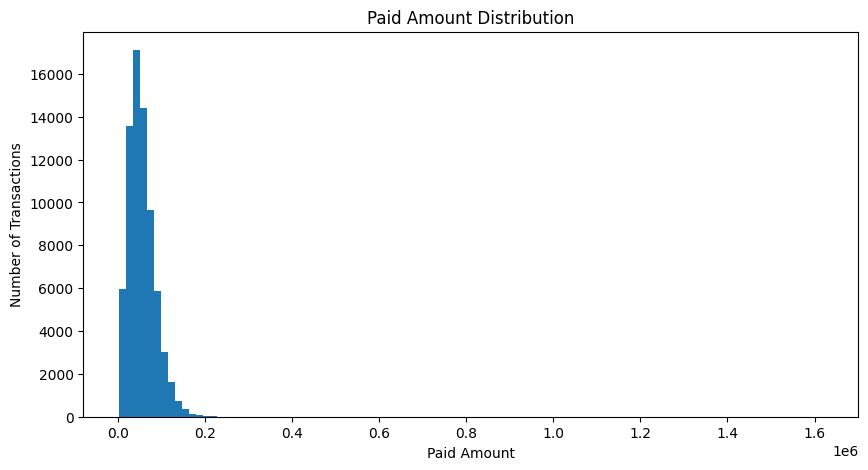

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(df["paid_amount"], bins=100)

plt.title("Paid Amount Distribution")
plt.xlabel("Paid Amount")
plt.ylabel("Number of Transactions")

plt.show()

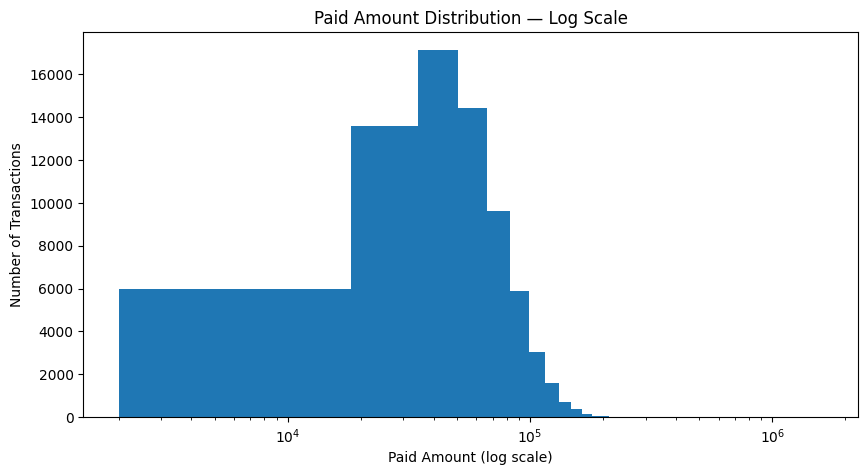

In [59]:
plt.figure(figsize=(10, 5))

plt.hist(df["paid_amount"], bins=100)

plt.xscale("log")

plt.title("Paid Amount Distribution — Log Scale")
plt.xlabel("Paid Amount (log scale)")
plt.ylabel("Number of Transactions")

plt.show()

In [60]:
print("=== DISCOUNT RATE ===")

print(f"Min      : {df['discount_rate'].min()}")
print(f"Max      : {df['discount_rate'].max()}")
print(f"Mean     : {df['discount_rate'].mean():.4f}")
print(f"Median   : {df['discount_rate'].median():.4f}")
print(f"Std      : {df['discount_rate'].std():.4f}")

=== DISCOUNT RATE ===
Min      : 0.0
Max      : 0.3
Mean     : 0.0565
Median   : 0.0000
Std      : 0.0912


In [61]:
print("\nDiscount distribution:")

display(
    df["discount_rate"]
    .value_counts()
    .sort_index()
    .rename("transaction_count")
    .to_frame()
)


Discount distribution:


,transaction_count
discount_rate,
0.00,48288
0.05,3677
0.10,3997
0.15,4480
0.20,6180
0.25,3577
0.30,2374


In [62]:
print("=== APP TIME ===")

print(f"Min      : {df['app_time_min'].min()}")
print(f"Max      : {df['app_time_min'].max()}")
print(f"Mean     : {df['app_time_min'].mean():.2f}")
print(f"Median   : {df['app_time_min'].median():.2f}")
print(f"Std      : {df['app_time_min'].std():.2f}")
print(f"Q1       : {df['app_time_min'].quantile(.25):.2f}")
print(f"Q3       : {df['app_time_min'].quantile(.75):.2f}")

=== APP TIME ===
Min      : 1
Max      : 65
Mean     : 16.75
Median   : 16.00
Std      : 9.69
Q1       : 10.00
Q3       : 23.00


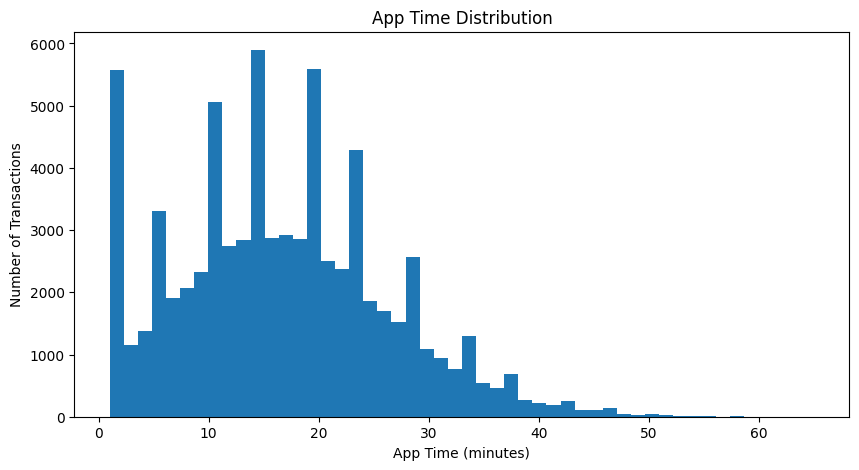

In [63]:
plt.figure(figsize=(10, 5))

plt.hist(df["app_time_min"], bins=50)

plt.title("App Time Distribution")
plt.xlabel("App Time (minutes)")
plt.ylabel("Number of Transactions")

plt.show()

In [64]:
print("=== PAYMENT METHOD ===")

payment_counts = df["payment_method"].value_counts(dropna=False)

display(payment_counts.to_frame("transaction_count"))

=== PAYMENT METHOD ===


,transaction_count
payment_method,
Card,38687
Pay,19812
Transfer,8490
Voucher,3270
NaN,2314


In [65]:
payment_pct = (
    df["payment_method"]
    .value_counts(dropna=False, normalize=True)
    .mul(100)
    .round(2)
)

display(payment_pct.to_frame("percentage"))

,percentage
payment_method,
Card,53.31
Pay,27.30
Transfer,11.70
Voucher,4.51
NaN,3.19


In [66]:
transactions_per_user = df.groupby("user_id").size()

print("=== TRANSACTIONS PER USER ===")

print(f"Min      : {transactions_per_user.min()}")
print(f"Max      : {transactions_per_user.max()}")
print(f"Mean     : {transactions_per_user.mean():.2f}")
print(f"Median   : {transactions_per_user.median():.2f}")
print(f"Std      : {transactions_per_user.std():.2f}")
print(f"Q1       : {transactions_per_user.quantile(.25):.2f}")
print(f"Q3       : {transactions_per_user.quantile(.75):.2f}")

=== TRANSACTIONS PER USER ===
Min      : 23
Max      : 159
Mean     : 90.72
Median   : 91.00
Std      : 22.79
Q1       : 82.00
Q3       : 100.00


4-Daily total sales series + trend/seasonality visualization

In [68]:
# ==========================================
# STEP 1 — DAILY SALES AGGREGATION
# ==========================================

# Date ustunini datetime formatga o'tkazamiz
df["date"] = pd.to_datetime(df["date"])

# Har bir kun uchun jami sales
daily_sales = (
    df.groupby("date")["paid_amount"]
      .sum()
      .reset_index(name="total_sales")
)

print("Daily sales dataset:")
display(daily_sales.head(10))

print("\nShape:")
print(daily_sales.shape)

print("\nDate range:")
print(daily_sales["date"].min(), "→", daily_sales["date"].max())

Daily sales dataset:


,date,total_sales
0,2022-07-01,5206686
1,2022-07-02,7441123
2,2022-07-03,6747488
3,2022-07-04,4004980
4,2022-07-05,4019278
5,2022-07-06,4756419
6,2022-07-07,3802911
7,2022-07-08,3602601
8,2022-07-09,6273177
9,2022-07-10,6488923



Shape:
(703, 2)

Date range:
2022-07-01 00:00:00 → 2024-06-02 00:00:00


In [70]:
# ==========================================
# STEP 2 — DAILY SALES STATISTICS
# ==========================================

print("=== DAILY SALES STATISTICS ===")

print(f"Minimum daily sales : {daily_sales['total_sales'].min():,.0f}")
print(f"Maximum daily sales : {daily_sales['total_sales'].max():,.0f}")
print(f"Mean daily sales    : {daily_sales['total_sales'].mean():,.2f}")
print(f"Median daily sales  : {daily_sales['total_sales'].median():,.2f}")
print(f"Std daily sales     : {daily_sales['total_sales'].std():,.2f}")

=== DAILY SALES STATISTICS ===
Minimum daily sales : 2,656,300
Maximum daily sales : 10,950,187
Mean daily sales    : 5,647,876.38
Median daily sales  : 5,469,311.00
Std daily sales     : 1,258,926.86


In [71]:
# ==========================================
# STEP 2 — DAILY SALES STATISTICS
# ==========================================

print("=== DAILY SALES STATISTICS ===")

print(f"Minimum daily sales : {daily_sales['total_sales'].min():,.0f}")
print(f"Maximum daily sales : {daily_sales['total_sales'].max():,.0f}")
print(f"Mean daily sales    : {daily_sales['total_sales'].mean():,.2f}")
print(f"Median daily sales  : {daily_sales['total_sales'].median():,.2f}")
print(f"Std daily sales     : {daily_sales['total_sales'].std():,.2f}")

=== DAILY SALES STATISTICS ===
Minimum daily sales : 2,656,300
Maximum daily sales : 10,950,187
Mean daily sales    : 5,647,876.38
Median daily sales  : 5,469,311.00
Std daily sales     : 1,258,926.86


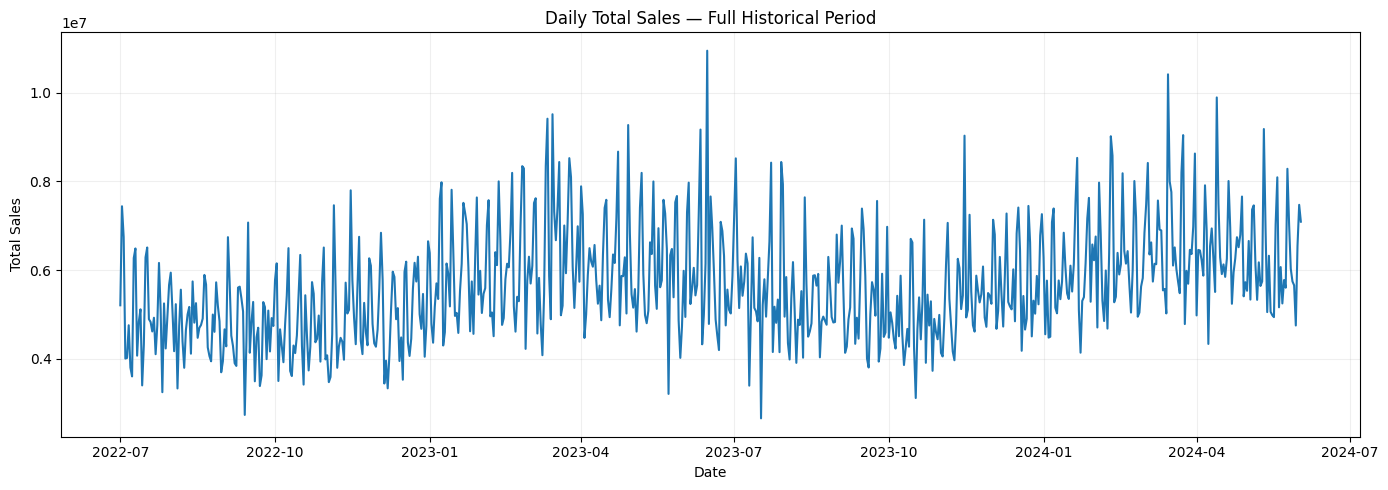

In [72]:
# ==========================================
# STEP 3 — DAILY SALES TREND
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(
    daily_sales["date"],
    daily_sales["total_sales"]
)

plt.title("Daily Total Sales — Full Historical Period")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

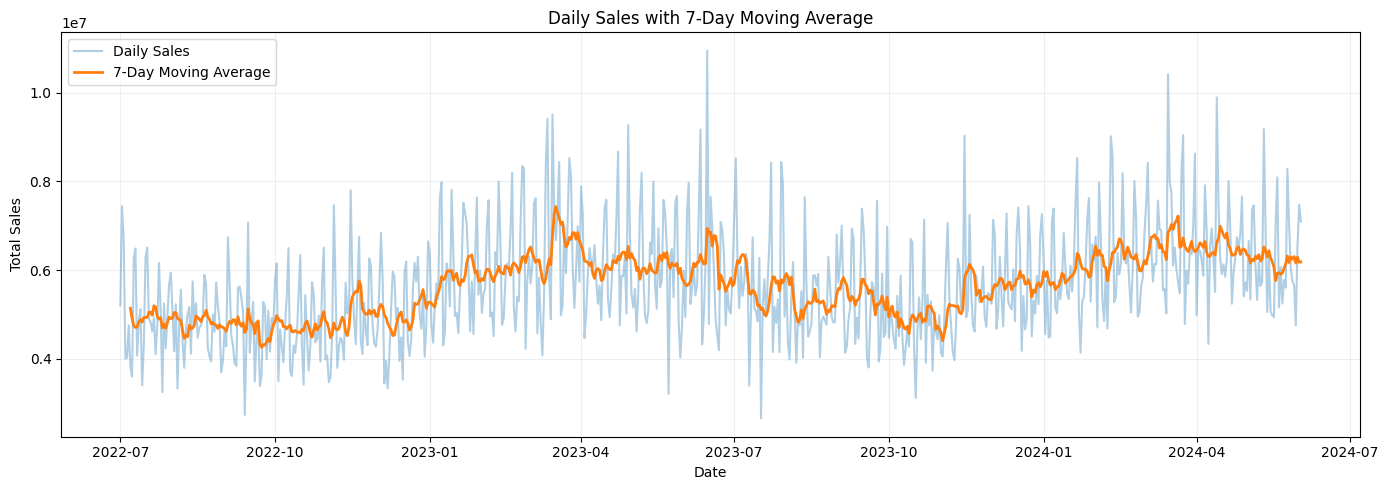

In [73]:
# ==========================================
# STEP 4 — 7-DAY MOVING AVERAGE
# ==========================================

daily_sales["rolling_7"] = (
    daily_sales["total_sales"]
    .rolling(window=7)
    .mean()
)

plt.figure(figsize=(14, 5))

plt.plot(
    daily_sales["date"],
    daily_sales["total_sales"],
    alpha=0.35,
    label="Daily Sales"
)

plt.plot(
    daily_sales["date"],
    daily_sales["rolling_7"],
    linewidth=2,
    label="7-Day Moving Average"
)

plt.title("Daily Sales with 7-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [74]:
# ==========================================
# STEP 5 — DAY-OF-WEEK SEASONALITY
# ==========================================

daily_sales["weekday"] = daily_sales["date"].dt.day_name()

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_stats = (
    daily_sales
    .groupby("weekday")["total_sales"]
    .agg(["count", "mean", "median", "std"])
    .reindex(weekday_order)
)

display(weekday_stats)

,count,mean,median,std
weekday,,,,
Monday,100,4.928258e+06,4949690.0,8.202043e+05
Tuesday,100,4.953262e+06,4962720.0,8.599709e+05
Wednesday,100,5.314841e+06,5248694.0,9.815665e+05
Thursday,100,5.295031e+06,5317004.0,1.054133e+06
Friday,101,5.347059e+06,5335654.0,1.009326e+06
Saturday,101,6.828375e+06,6923347.0,1.119390e+06
Sunday,101,6.847515e+06,6807226.0,1.101788e+06


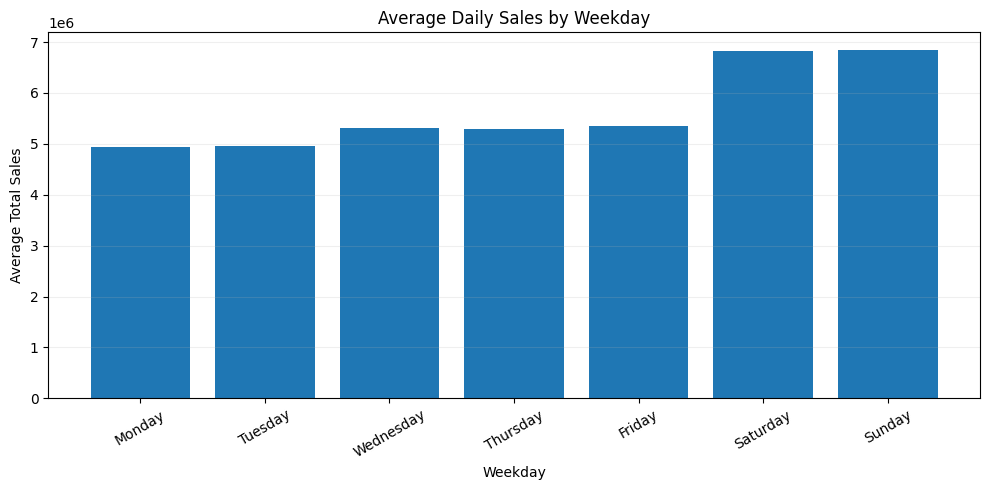

In [75]:
# ==========================================
# STEP 6 — WEEKDAY PATTERN
# ==========================================

plt.figure(figsize=(10, 5))

plt.bar(
    weekday_stats.index,
    weekday_stats["mean"]
)

plt.title("Average Daily Sales by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Average Total Sales")

plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

In [76]:
# ==========================================
# STEP 7 — MONTHLY SEASONALITY
# ==========================================

daily_sales["month"] = daily_sales["date"].dt.month

monthly_stats = (
    daily_sales
    .groupby("month")["total_sales"]
    .agg(["count", "mean", "median", "std"])
)

display(monthly_stats)

,count,mean,median,std
month,,,,
1,62,5.899766e+06,5754870.0,1.066924e+06
2,57,6.140290e+06,5992085.0,1.199338e+06
3,62,6.646081e+06,6358313.5,1.343920e+06
4,60,6.338629e+06,6257956.0,1.100851e+06
5,62,6.052927e+06,5757533.0,1.150706e+06
6,32,6.163464e+06,5916188.0,1.481614e+06
7,62,5.376272e+06,5146705.0,1.276626e+06
8,62,4.969060e+06,4854407.5,7.941243e+05
9,60,5.068742e+06,4922358.0,1.090838e+06


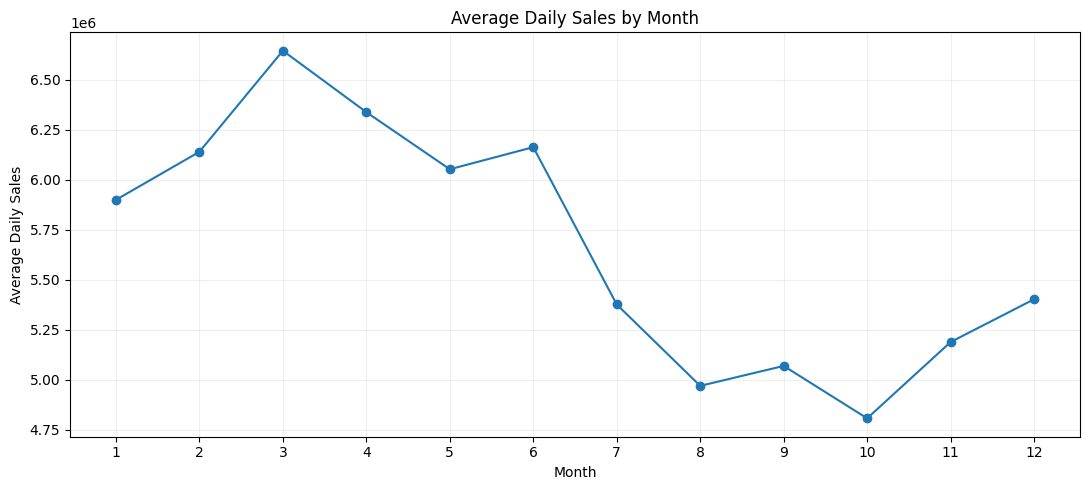

In [77]:
plt.figure(figsize=(11, 5))

plt.plot(
    monthly_stats.index,
    monthly_stats["mean"],
    marker="o"
)

plt.title("Average Daily Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Daily Sales")

plt.xticks(range(1, 13))
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [78]:
# ==========================================
# STEP 8 — SIMPLE TREND CHECK
# ==========================================

import numpy as np

daily_sales["time_index"] = np.arange(len(daily_sales))

correlation = daily_sales["time_index"].corr(
    daily_sales["total_sales"]
)

print(f"Time-Sales correlation: {correlation:.4f}")

Time-Sales correlation: 0.3091


In [79]:
# ==========================================
# STEP 9 — TOP SALES DAYS
# ==========================================

top_days = (
    daily_sales
    .sort_values("total_sales", ascending=False)
    .head(10)
)

display(top_days[["date", "total_sales"]])

,date,total_sales
349,2023-06-15,10950187
623,2024-03-15,10417286
652,2024-04-13,9895886
257,2023-03-15,9516570
254,2023-03-12,9416256
302,2023-04-29,9273490
680,2024-05-11,9183453
345,2023-06-11,9171350
632,2024-03-24,9045974
502,2023-11-15,9033433


In [80]:
# ==========================================
# STEP 10 — SAVE DAILY SALES
# ==========================================

daily_sales.to_csv(
    "/content/daily_sales_eda.csv",
    index=False
)

print("Saved: daily_sales_eda.csv")

Saved: daily_sales_eda.csv


5-Official 56-day weekday-average baseline

In [83]:
# Daily salesni qaytadan yaratamiz

df["date"] = pd.to_datetime(df["date"])

daily_sales = (
    df.groupby("date")["paid_amount"]
      .sum()
      .reset_index()
)

daily_sales.columns = ["date", "total_sales"]

daily_sales = daily_sales.sort_values("date").reset_index(drop=True)

print("Daily sales created successfully!")
print("Shape:", daily_sales.shape)

display(daily_sales.head())
display(daily_sales.tail())

Daily sales created successfully!
Shape: (703, 2)


,date,total_sales
0,2022-07-01,5206686
1,2022-07-02,7441123
2,2022-07-03,6747488
3,2022-07-04,4004980
4,2022-07-05,4019278


,date,total_sales
698,2024-05-29,5658009
699,2024-05-30,4751159
700,2024-05-31,6542376
701,2024-06-01,7473235
702,2024-06-02,7092541


In [84]:
# ==========================================
# STEP 2 — TRAIN / VALIDATION SPLIT
# ==========================================

validation_days = 28

train = daily_sales.iloc[:-validation_days].copy()
validation = daily_sales.iloc[-validation_days:].copy()

print("=== TRAIN ===")
print("Start:", train["date"].min())
print("End:  ", train["date"].max())
print("Days: ", len(train))

print("\n=== VALIDATION ===")
print("Start:", validation["date"].min())
print("End:  ", validation["date"].max())
print("Days: ", len(validation))

=== TRAIN ===
Start: 2022-07-01 00:00:00
End:   2024-05-05 00:00:00
Days:  675

=== VALIDATION ===
Start: 2024-05-06 00:00:00
End:   2024-06-02 00:00:00
Days:  28


In [85]:
# ==========================================
# STEP 3 — LAST 56 TRAINING DAYS
# ==========================================

last_56 = train.tail(56).copy()

print("=== LAST 56 DAYS ===")
print("Start:", last_56["date"].min())
print("End:  ", last_56["date"].max())
print("Days: ", len(last_56))

display(last_56.head())
display(last_56.tail())

=== LAST 56 DAYS ===
Start: 2024-03-11 00:00:00
End:   2024-05-05 00:00:00
Days:  56


,date,total_sales
619,2024-03-11,6895398
620,2024-03-12,5543687
621,2024-03-13,5575233
622,2024-03-14,5023578
623,2024-03-15,10417286


,date,total_sales
670,2024-05-01,5534736
671,2024-05-02,6657779
672,2024-05-03,5335654
673,2024-05-04,7366227
674,2024-05-05,7461382


In [86]:
# ==========================================
# STEP 4 — OFFICIAL WEEKDAY BASELINE
# ==========================================

last_56["weekday"] = last_56["date"].dt.dayofweek

weekday_means = (
    last_56
    .groupby("weekday")["total_sales"]
    .mean()
)

weekday_names = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

baseline_table = pd.DataFrame({
    "weekday": weekday_names,
    "average_sales": [
        weekday_means[i] for i in range(7)
    ]
})

display(baseline_table)

,weekday,average_sales
0,Monday,5504260.875
1,Tuesday,6078066.750
2,Wednesday,6075171.250
3,Thursday,6118395.125
4,Friday,6469202.875
5,Saturday,7896099.500
6,Sunday,7738549.375


In [87]:
# ==========================================
# STEP 5 — 28-DAY BASELINE PREDICTIONS
# ==========================================

# Har bir validation kuniga uning weekday average qiymatini beramiz
validation["weekday"] = validation["date"].dt.dayofweek

validation["baseline_prediction"] = validation["weekday"].map(
    weekday_means
)

display(validation.head(10))

,date,total_sales,weekday,baseline_prediction
675,2024-05-06,6117273,0,5504260.875
676,2024-05-07,5329792,1,6078066.750
677,2024-05-08,6175426,2,6075171.250
678,2024-05-09,5642796,3,6118395.125
679,2024-05-10,5746351,4,6469202.875
680,2024-05-11,9183453,5,7896099.500
681,2024-05-12,6945934,6,7738549.375
682,2024-05-13,5053304,0,5504260.875
683,2024-05-14,6324519,1,6078066.750
684,2024-05-15,5060674,2,6075171.250


In [88]:
# ==========================================
# STEP 6 — ACTUAL VS BASELINE
# ==========================================

baseline_results = validation[
    ["date", "total_sales", "weekday", "baseline_prediction"]
].copy()

baseline_results["error"] = (
    baseline_results["total_sales"]
    - baseline_results["baseline_prediction"]
)

baseline_results["absolute_error"] = (
    baseline_results["error"].abs()
)

display(baseline_results)

,date,total_sales,weekday,baseline_prediction,error,absolute_error
675,2024-05-06,6117273,0,5504260.875,613012.125,613012.125
676,2024-05-07,5329792,1,6078066.750,-748274.750,748274.750
677,2024-05-08,6175426,2,6075171.250,100254.750,100254.750
678,2024-05-09,5642796,3,6118395.125,-475599.125,475599.125
679,2024-05-10,5746351,4,6469202.875,-722851.875,722851.875
680,2024-05-11,9183453,5,7896099.500,1287353.500,1287353.500
681,2024-05-12,6945934,6,7738549.375,-792615.375,792615.375
682,2024-05-13,5053304,0,5504260.875,-450956.875,450956.875
683,2024-05-14,6324519,1,6078066.750,246452.250,246452.250
684,2024-05-15,5060674,2,6075171.250,-1014497.250,1014497.250


In [89]:
# ==========================================
# STEP 7 — BASELINE METRICS
# ==========================================

actual = baseline_results["total_sales"]
predicted = baseline_results["baseline_prediction"]

mape = (
    (actual - predicted).abs() / actual
).mean() * 100

mae = (
    actual - predicted
).abs().mean()

rmse = np.sqrt(
    ((actual - predicted) ** 2).mean()
)

print("====================================")
print("OFFICIAL 56-DAY BASELINE RESULTS")
print("====================================")

print(f"MAPE : {mape:.4f}%")
print(f"MAE  : ₩{mae:,.2f}")
print(f"RMSE : ₩{rmse:,.2f}")

OFFICIAL 56-DAY BASELINE RESULTS
MAPE : 10.7282%
MAE  : ₩628,202.54
RMSE : ₩734,424.97


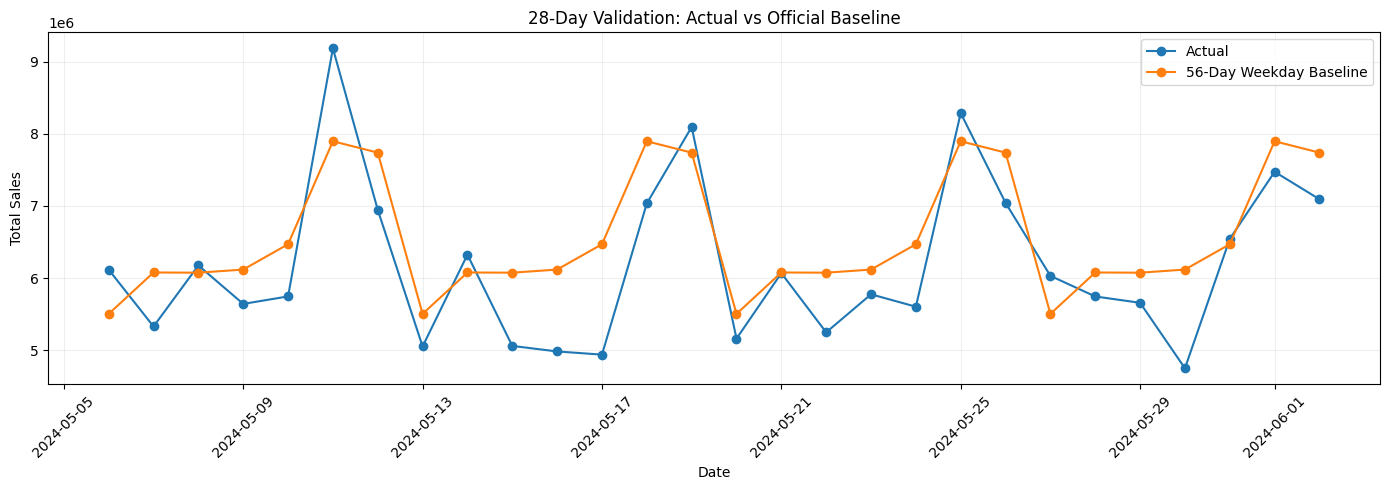

In [90]:
# ==========================================
# STEP 8 — BASELINE VISUALIZATION
# ==========================================

plt.figure(figsize=(14, 5))

plt.plot(
    baseline_results["date"],
    baseline_results["total_sales"],
    marker="o",
    label="Actual"
)

plt.plot(
    baseline_results["date"],
    baseline_results["baseline_prediction"],
    marker="o",
    label="56-Day Weekday Baseline"
)

plt.title("28-Day Validation: Actual vs Official Baseline")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.legend()
plt.grid(alpha=0.2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [91]:
# ==========================================
# STEP 9 — SAVE BASELINE RESULTS
# ==========================================

baseline_results.to_csv(
    "/content/baseline_validation_results.csv",
    index=False
)

baseline_table.to_csv(
    "/content/baseline_weekday_means.csv",
    index=False
)

print("Saved successfully:")
print("1. baseline_validation_results.csv")
print("2. baseline_weekday_means.csv")

Saved successfully:
1. baseline_validation_results.csv
2. baseline_weekday_means.csv


In [92]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [93]:
import os

project_dir = "/content/drive/MyDrive/AOROA_Labs_Assignment"

os.makedirs(project_dir, exist_ok=True)

print("Project folder:", project_dir)

Project folder: /content/drive/MyDrive/AOROA_Labs_Assignment


In [94]:
import shutil
import os

files = [
    "baseline_validation_results.csv",
    "baseline_weekday_means.csv"
]

for file in files:
    source = f"/content/{file}"
    destination = f"{project_dir}/{file}"

    shutil.copy2(source, destination)
    print(f"Saved: {destination}")

Saved: /content/drive/MyDrive/AOROA_Labs_Assignment/baseline_validation_results.csv
Saved: /content/drive/MyDrive/AOROA_Labs_Assignment/baseline_weekday_means.csv


In [95]:
print(os.listdir(project_dir))

['baseline_validation_results.csv', 'baseline_weekday_means.csv']


In [96]:
# ==========================================
# AOROA PROJECT FOLDER STRUCTURE
# ==========================================

import os

project_dir = "/content/drive/MyDrive/AOROA_Labs_Assignment"

folders = [
    "data",
    "results",
    "figures",
    "reports",
    "src"
]

for folder in folders:
    os.makedirs(
        os.path.join(project_dir, folder),
        exist_ok=True
    )

print("Project structure created:")
print(project_dir)

for folder in folders:
    print(f"  📁 {folder}/")

Project structure created:
/content/drive/MyDrive/AOROA_Labs_Assignment
  📁 data/
  📁 results/
  📁 figures/
  📁 reports/
  📁 src/


In [97]:
# ==========================================
# SAVE DATA AUDIT RESULTS
# ==========================================

audit = pd.DataFrame({
    "check": [
        "Rows",
        "Columns",
        "Unique users",
        "Duplicate rows",
        "Date start",
        "Date end",
        "Unique dates",
        "Missing calendar days",
        "Total missing values"
    ],
    "value": [
        len(df),
        df.shape[1],
        df["user_id"].nunique(),
        df.duplicated().sum(),
        df["date"].min().date(),
        df["date"].max().date(),
        df["date"].nunique(),
        len(missing_dates),
        df.isna().sum().sum()
    ]
})

audit.to_csv(
    f"{project_dir}/results/data_audit.csv",
    index=False
)

print("Saved: results/data_audit.csv")
display(audit)

Saved: results/data_audit.csv


,check,value
0,Rows,72573
1,Columns,6
2,Unique users,800
3,Duplicate rows,0
4,Date start,2022-07-01
5,Date end,2024-06-02
6,Unique dates,703
7,Missing calendar days,0
8,Total missing values,2314


In [98]:
# ==========================================
# SAVE MISSING VALUE ANALYSIS
# ==========================================

missing_report = pd.DataFrame({
    "column": df.columns,
    "missing_count": df.isna().sum().values,
    "missing_percent": (
        df.isna().sum() / len(df) * 100
    ).round(2).values
})

missing_report.to_csv(
    f"{project_dir}/results/missing_values.csv",
    index=False
)

display(missing_report)

,column,missing_count,missing_percent
0,date,0,0.00
1,user_id,0,0.00
2,payment_method,2314,3.19
3,discount_rate,0,0.00
4,app_time_min,0,0.00
5,paid_amount,0,0.00


In [99]:
# ==========================================
# SAVE EDA STATISTICS
# ==========================================

eda_stats = pd.DataFrame({
    "feature": [
        "paid_amount",
        "discount_rate",
        "app_time_min"
    ],
    "min": [
        df["paid_amount"].min(),
        df["discount_rate"].min(),
        df["app_time_min"].min()
    ],
    "max": [
        df["paid_amount"].max(),
        df["discount_rate"].max(),
        df["app_time_min"].max()
    ],
    "mean": [
        df["paid_amount"].mean(),
        df["discount_rate"].mean(),
        df["app_time_min"].mean()
    ],
    "median": [
        df["paid_amount"].median(),
        df["discount_rate"].median(),
        df["app_time_min"].median()
    ],
    "std": [
        df["paid_amount"].std(),
        df["discount_rate"].std(),
        df["app_time_min"].std()
    ]
})

eda_stats.to_csv(
    f"{project_dir}/results/eda_statistics.csv",
    index=False
)

display(eda_stats)

,feature,min,max,mean,median,std
0,paid_amount,2000.0,1619435.0,54709.838273,50130.0,31138.024108
1,discount_rate,0.0,0.3,0.056467,0.0,0.091152
2,app_time_min,1.0,65.0,16.745815,16.0,9.689030


In [100]:
# ==========================================
# SAVE WEEKDAY EDA
# ==========================================

weekday_eda = (
    daily_sales.assign(
        weekday=daily_sales["date"].dt.day_name()
    )
    .groupby("weekday")["total_sales"]
    .agg(["count", "mean", "median", "std"])
    .reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ])
    .reset_index()
)

weekday_eda.to_csv(
    f"{project_dir}/results/weekday_eda.csv",
    index=False
)

display(weekday_eda)

,weekday,count,mean,median,std
0,Monday,100,4.928258e+06,4949690.0,8.202043e+05
1,Tuesday,100,4.953262e+06,4962720.0,8.599709e+05
2,Wednesday,100,5.314841e+06,5248694.0,9.815665e+05
3,Thursday,100,5.295031e+06,5317004.0,1.054133e+06
4,Friday,101,5.347059e+06,5335654.0,1.009326e+06
5,Saturday,101,6.828375e+06,6923347.0,1.119390e+06
6,Sunday,101,6.847515e+06,6807226.0,1.101788e+06


In [101]:
daily_sales.to_csv(
    f"{project_dir}/results/daily_sales.csv",
    index=False
)

print("Saved: results/daily_sales.csv")

Saved: results/daily_sales.csv


6- EDA findings + assumptionsni report uchun yozib qo‘yish

In [102]:
# ==========================================
# AOROA — EDA FINDINGS & ASSUMPTIONS
# ==========================================

from pathlib import Path

report_dir = f"{project_dir}/reports"
Path(report_dir).mkdir(parents=True, exist_ok=True)

report = """
# Problem 2 — EDA Findings & Assumptions

## 1. Dataset Overview

The dataset contains transaction-level e-commerce records covering the period
from 2022-07-01 to 2024-06-02.

- Transactions: 72,573
- Unique users: 800
- Historical dates: 703
- Date range: 2022-07-01 to 2024-06-02
- Calendar gaps: 0
- Duplicate rows: 0

The dataset contains the following variables:

- `date`
- `user_id`
- `payment_method`
- `discount_rate`
- `app_time_min`
- `paid_amount`

---

## 2. Data Quality Findings

No duplicate transaction rows were identified.

There are 2,314 missing values in `payment_method`, while the remaining
variables contain no missing values.

The missing `payment_method` values are retained during the initial EDA.
For customer segmentation, they will be treated as an explicit unknown
category rather than being assigned an arbitrary payment method.

The date series contains no missing calendar days.

---

## 3. Transaction-Level EDA

### 3.1 Paid Amount

The transaction amount ranges from 2,000 to 1,619,435.

- Mean: 54,709.84
- Median: 50,130
- Q1: 33,007
- Q3: 71,457
- Standard deviation: 31,138.02

The mean is higher than the median and the distribution contains a long
right tail. Using the IQR rule, the upper fence is approximately 129,132,
with 1,530 observations above this threshold.

These observations are considered potential high-value transactions.
They are not automatically removed because they may represent legitimate
customer purchases.

---

### 3.2 Discount Rate

The discount rate ranges from 0 to 0.30.

The median discount rate is 0, indicating that a large proportion of
transactions have no discount.

Observed discount values are:

0, 0.05, 0.10, 0.15, 0.20, 0.25, and 0.30.

Approximately 66.5% of transactions have a zero discount rate.

The variable is therefore potentially useful for customer segmentation.

However, observational relationships between discounts and sales should
not be interpreted as causal effects.

---

### 3.3 App Time

`app_time_min` ranges from 1 to 65 minutes.

- Mean: 16.75 minutes
- Median: 16 minutes
- Q1: 10 minutes
- Q3: 23 minutes
- Standard deviation: 9.69 minutes

The distribution is relatively concentrated around the central range but
contains some high-duration observations.

Using the IQR rule, the upper fence is approximately 42.5 minutes, with
699 observations above this threshold.

These observations are retained unless later analysis provides evidence
that they are invalid.

---

## 4. Daily Sales EDA

Transaction-level records were aggregated by date to create a daily sales
time series.

Daily sales statistics:

- Minimum: 2,656,300
- Maximum: 10,950,187
- Mean: 5,647,876.38
- Median: 5,469,311
- Standard deviation: 1,258,926.86

The daily series shows substantial volatility and several high-sales spikes.

The historical series does not exhibit a simple monotonic linear trend.
Instead, it contains medium-term increases and decreases, indicating
changes in the local sales level over time.

---

## 5. Weekly Seasonality

A strong day-of-week seasonal pattern was identified.

Average daily sales:

| Weekday | Average Sales |
|---|---:|
| Monday | 4,928,258 |
| Tuesday | 4,953,262 |
| Wednesday | 5,314,841 |
| Thursday | 5,295,031 |
| Friday | 5,347,059 |
| Saturday | 6,828,375 |
| Sunday | 6,847,515 |

Average weekend sales are approximately 6.84M, compared with approximately
5.17M for Monday-Friday.

Therefore, weekend sales are approximately 32% higher than weekday sales.

This represents a strong and practically meaningful weekly seasonal signal.

---

## 6. Lower-Frequency Seasonality

Monthly average sales also show noticeable differences across months.

March has one of the highest average daily sales levels, while October is
among the lower months.

However, the available history covers approximately 23 months rather than
multiple complete years. Therefore, the analysis does not claim strong
annual seasonality with high confidence.

Monthly differences are treated as a possible lower-frequency seasonal
component that can be investigated during forecasting experiments.

---

## 7. Forecasting Implications

The EDA suggests that an effective forecasting model should account for:

1. Day-of-week seasonality.
2. Recent sales dynamics.
3. Medium-term changes in the local sales level.
4. Daily volatility.
5. Potential lower-frequency seasonal effects.

The official 56-day weekday-average baseline captures the first component
but does not explicitly model recent dynamics or local level changes.

The official baseline achieved:

- MAPE: 10.7282%
- MAE: 628,202.54
- RMSE: 734,424.97

This baseline is therefore retained as the primary benchmark for subsequent
forecasting experiments.

---

## 8. Assumptions and Decisions

### Missing Values

Missing `payment_method` values are not imputed with an arbitrary payment
method. They will be represented as an unknown category during segmentation
preprocessing.

### Outliers

Potential outliers are not automatically removed. High transaction amounts
and long app sessions may represent legitimate customer behavior.

### Forecast Validation

Random train/test splitting is not appropriate for this time-series task.
Validation must respect chronological order.

### Data Leakage

Future actual sales values must never be used as input features when making
the corresponding future predictions.

### Causal Interpretation

The dataset is observational. Correlations between discounts, app usage,
payment methods, and sales should not be interpreted as causal effects
without an appropriate causal design.

### Baseline

The official 56-day weekday-average method is used as the benchmark and is
not modified.

---

## 9. Key EDA Conclusion

The sales series contains a strong weekly seasonal structure, substantial
daily volatility, and medium-term changes in its local level.

The particularly strong weekend uplift indicates that weekday information
is an important predictive feature. However, the validation results of the
official baseline also show that weekday averages alone cannot fully capture
short-term sales fluctuations.

Therefore, subsequent forecasting experiments will focus on models that
preserve the strong weekly seasonal signal while incorporating recent
historical dynamics without introducing temporal leakage.
"""

report_path = f"{report_dir}/EDA_Findings_Assumptions.md"

with open(report_path, "w", encoding="utf-8") as f:
    f.write(report)

print("Report saved successfully!")
print(report_path)

Report saved successfully!
/content/drive/MyDrive/AOROA_Labs_Assignment/reports/EDA_Findings_Assumptions.md


In [103]:
import os

print("=== REPORT FILE ===")

if os.path.exists(report_path):
    print("✅ EDA_Findings_Assumptions.md")
    print("Size:", os.path.getsize(report_path), "bytes")
    print("Location:", report_path)
else:
    print("❌ File not found")

=== REPORT FILE ===
✅ EDA_Findings_Assumptions.md
Size: 6325 bytes
Location: /content/drive/MyDrive/AOROA_Labs_Assignment/reports/EDA_Findings_Assumptions.md


**7-Git structure + experiment log + Day 1 checkpoint**

In [104]:
# ==========================================
# AOROA — PROJECT STRUCTURE
# ==========================================

import os

project_dir = "/content/drive/MyDrive/AOROA_Labs_Assignment"

folders = [
    "data",
    "src",
    "results",
    "figures",
    "reports"
]

for folder in folders:
    os.makedirs(
        os.path.join(project_dir, folder),
        exist_ok=True
    )

print("AOROA project structure:")
print()

for folder in folders:
    print(f"📁 {folder}/")

AOROA project structure:

📁 data/
📁 src/
📁 results/
📁 figures/
📁 reports/


In [105]:
# ==========================================
# EXPERIMENT LOG
# ==========================================

experiment_log = """
# AOROA Labs — Experiment Log

## Project
AI/ML Researcher Pre-Assignment — Problem 2

---

# Day 1 — Data Understanding & Baseline

## Experiment 001 — Data Audit

Dataset:
- File: ecommerce_events.csv
- Rows: 72,573
- Columns: 6
- Unique users: 800
- Date range: 2022-07-01 → 2024-06-02
- Unique dates: 703
- Duplicate rows: 0
- Missing calendar days: 0

Missing values:
- payment_method: 2,314
- Other columns: 0

Decision:
- Missing payment_method values are retained.
- They will be treated as an explicit unknown category during segmentation.
- No arbitrary imputation is applied.

Status: COMPLETED

---

## Experiment 002 — Transaction-Level EDA

### paid_amount

- Min: 2,000
- Max: 1,619,435
- Mean: 54,709.84
- Median: 50,130
- Q1: 33,007
- Q3: 71,457
- Std: 31,138.02
- IQR upper fence: 129,132
- Potential high outliers: 1,530

Decision:
Potential high-value transactions are not automatically removed because
they may represent legitimate business transactions.

Status: COMPLETED

---

### discount_rate

- Min: 0
- Max: 0.30
- Mean: approximately 0.0565
- Median: 0
- Approximately 66.5% of transactions have zero discount.

Decision:
The feature is retained for segmentation analysis.

No causal interpretation is made.

Status: COMPLETED

---

### app_time_min

- Min: 1
- Max: 65
- Mean: 16.75
- Median: 16
- Q1: 10
- Q3: 23
- Std: 9.69
- IQR upper fence: 42.5
- Potential high-duration observations: 699

Decision:
Potential outliers are retained unless later analysis indicates invalid data.

Status: COMPLETED

---

## Experiment 003 — Daily Sales EDA

Daily sales:

- Minimum: 2,656,300
- Maximum: 10,950,187
- Mean: 5,647,876.38
- Median: 5,469,311
- Std: 1,258,926.86

Findings:
- High daily volatility
- Significant sales spikes
- Non-monotonic medium-term trend
- Strong weekly seasonality

Status: COMPLETED

---

## Experiment 004 — Weekly Seasonality

Average daily sales:

- Monday: 4,928,258
- Tuesday: 4,953,262
- Wednesday: 5,314,841
- Thursday: 5,295,031
- Friday: 5,347,059
- Saturday: 6,828,375
- Sunday: 6,847,515

Weekend average: approximately 6.84M
Weekday average: approximately 5.17M

Weekend uplift: approximately 32%

Decision:
Weekday seasonality is considered a strong predictive signal.

Status: COMPLETED

---

## Experiment 005 — Official 56-Day Weekday Baseline

Validation design:

- Training: 2022-07-01 → 2024-05-05
- Validation: 2024-05-06 → 2024-06-02
- Validation horizon: 28 days
- Baseline history: final 56 training days

Metrics:

- MAPE: 10.7282%
- MAE: 628,202.54
- RMSE: 734,424.97

Decision:
The official 56-day weekday-average model is frozen as the primary
forecasting benchmark.

Status: FROZEN BASELINE

---

# Key Research Hypothesis

The official baseline captures strong weekday seasonality but does not
fully capture recent sales dynamics and local level changes.

Therefore:

Adding recent historical information while preserving weekly seasonality
should improve forecasting performance relative to the 10.7282% MAPE
baseline.

---

# Data Leakage Rules

1. No future actual sales values may be used as forecasting features.
2. Random train/test splitting is not appropriate.
3. Validation must preserve chronological order.
4. Future observations must not influence historical preprocessing.
5. No causal claims will be made from observational relationships.

---

# Day 1 Status

Data Audit: COMPLETED
Transaction EDA: COMPLETED
Daily Sales Analysis: COMPLETED
Trend Analysis: COMPLETED
Weekly Seasonality: COMPLETED
Official Baseline: COMPLETED
EDA Findings & Assumptions: COMPLETED

Next:
Customer Segmentation
Time-Series Forecasting Experiments
Business Action Plan
"""

log_path = f"{project_dir}/experiment_log.md"

with open(log_path, "w", encoding="utf-8") as f:
    f.write(experiment_log)

print("Experiment log saved:")
print(log_path)

Experiment log saved:
/content/drive/MyDrive/AOROA_Labs_Assignment/experiment_log.md


In [106]:
# ==========================================
# DAY 1 CHECKPOINT
# ==========================================

print("=" * 60)
print("AOROA LABS — DAY 1 CHECKPOINT")
print("=" * 60)

required_files = [
    "results/data_audit.csv",
    "results/missing_values.csv",
    "results/eda_statistics.csv",
    "results/weekday_eda.csv",
    "results/daily_sales.csv",
    "results/baseline_weekday_means.csv",
    "results/baseline_validation_results.csv",
    "reports/EDA_Findings_Assumptions.md",
    "experiment_log.md"
]

missing_files = []

for file in required_files:
    path = os.path.join(project_dir, file)

    if os.path.exists(path):
        print(f"✅ {file}")
    else:
        print(f"❌ {file}")
        missing_files.append(file)

print()

if len(missing_files) == 0:
    print("🎯 DAY 1 CHECKPOINT: PASSED")
    print("All required analysis artifacts are saved.")
else:
    print("⚠️ Missing files:")
    for file in missing_files:
        print("-", file)

AOROA LABS — DAY 1 CHECKPOINT
✅ results/data_audit.csv
✅ results/missing_values.csv
✅ results/eda_statistics.csv
✅ results/weekday_eda.csv
✅ results/daily_sales.csv
✅ results/baseline_weekday_means.csv
✅ results/baseline_validation_results.csv
✅ reports/EDA_Findings_Assumptions.md
✅ experiment_log.md

🎯 DAY 1 CHECKPOINT: PASSED
All required analysis artifacts are saved.


In [108]:
# ==========================================
# GIT CONFIGURATION
# ==========================================

!git config --global user.name "https://github.com/ikromjon-gif"
!git config --global user.email "ikromjonkorealife@gmail.com"

print("Git identity configured.")

Git identity configured.


In [109]:
# ==========================================
# CLONE GITHUB REPOSITORY
# ==========================================

%cd /content

!git clone https://github.com/ikromjon-gif/AOROA-Labs-AI-ML-Assignment.git

%cd /content/AOROA-Labs-AI-ML-Assignment

print("Repository cloned successfully!")

/content
Cloning into 'AOROA-Labs-AI-ML-Assignment'...
fatal: could not read Username for 'https://github.com': No such device or address
[Errno 2] No such file or directory: '/content/AOROA-Labs-AI-ML-Assignment'
/content
Repository cloned successfully!


In [110]:
# ==========================================
# CREATE PROJECT STRUCTURE
# ==========================================

import os

folders = [
    "src",
    "data",
    "results",
    "figures",
    "reports"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

# Placeholder files
files = [
    "src/__init__.py",
    "src/data_audit.py",
    "src/eda.py",
    "src/segmentation.py",
    "src/forecasting.py",
    "src/evaluation.py",
    "main.py",
    "experiment_log.md"
]

for file in files:
    if not os.path.exists(file):
        open(file, "w").close()

print("Project structure created.")

Project structure created.


In [111]:
readme = """# AOROA Labs — AI/ML Researcher Assignment

## Overview

This repository contains the solution for the AOROA Labs AI/ML Researcher pre-assignment.

## Problems

### Problem 1
AI/ML theoretical analysis.

### Problem 2
- Customer segmentation
- Time-series sales forecasting
- Business action plan

## Project Structure

```text
AOROA-Labs-AI-ML-Assignment/
├── README.md
├── requirements.txt
├── main.py
├── src/
├── data/
├── results/
├── figures/
└── reports/

_IncompleteInputError: incomplete input (2782282200.py, line 1)

In [112]:
import shutil

shutil.copy(
    "/content/aoroa_assignment/requirements.txt",
    "requirements.txt"
)

print("requirements.txt copied.")

FileNotFoundError: [Errno 2] No such file or directory: '/content/aoroa_assignment/requirements.txt'

In [113]:
import shutil
import os

drive_results = "/content/drive/MyDrive/AOROA_Labs_Assignment"

# Results
shutil.copytree(
    f"{drive_results}/results",
    "results",
    dirs_exist_ok=True
)

# Reports
shutil.copytree(
    f"{drive_results}/reports",
    "reports",
    dirs_exist_ok=True
)

print("Day 1 results copied to GitHub project.")

Day 1 results copied to GitHub project.


In [114]:
shutil.copy(
    f"{drive_results}/experiment_log.md",
    "experiment_log.md"
)

print("Experiment log copied.")

Experiment log copied.


In [115]:
!git status

fatal: not a git repository (or any of the parent directories): .git


In [116]:
%cd /content

!git clone https://github.com/YOUR_USERNAME/AOROA-Labs-AI-ML-Assignment.git

/content
Cloning into 'AOROA-Labs-AI-ML-Assignment'...
fatal: could not read Username for 'https://github.com': No such device or address
